In [44]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [45]:
import os
import sys
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle
from scipy import stats

from imports import *
from config import dir_config, main_config
from src.utils import pmf_utils
# from src.glm_hmm


In [46]:

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define directories
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

# glm_hmm_config = main_config["GLM_HMM"]
# CURRENT_TRIAL_FEATURES = glm_hmm_config["current_trial_features"] + ["bias"] if glm_hmm_config["add_bias"] else glm_hmm_config["current_trial_features"]
# PREV_TRIAL_FEATURES = glm_hmm_config["prev_trial_features"]
# N_TRIALS_BACK = glm_hmm_config["n_trials_back"]

# MODEL_FEATURES = CURRENT_TRIAL_FEATURES + [f"{var}_{n + 1}" for n in range(N_TRIALS_BACK) for var in PREV_TRIAL_FEATURES]
# glm_hmm_config["model_features"] = MODEL_FEATURES

# INPUT_DIM = len(MODEL_FEATURES)
# MODEL_NAME = glm_hmm_config["name"]

In [47]:
MODEL_NAME = "masked_no_bias_1_back_prev_choice_coherence"
MAX_STATE = 5

### Load data and model

In [48]:
model_paths = Path(glm_hmm_dir / MODEL_NAME).glob("*.pkl")

In [49]:
models_and_data = {}
for model_path in model_paths:
    with open(model_path, "rb") as f:
        model_data = pickle.load(f)
        models_and_data[model_path.stem] = model_data

### Plot per group likelihoods

In [50]:
def plot_model_comparison(fitted_dict: dict):

    train_ll = np.mean(fitted_dict["session_wise"]["train_ll"], axis=(0,2))
    test_ll = np.mean(fitted_dict["session_wise"]["test_ll"], axis=(0,2))
    states = np.arange(1, len(fitted_dict["session_wise"]["models"][0].keys()) + 1)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # First y-axis: Train LL
    ax1.plot(states, train_ll, marker="o", markersize=15, linewidth=3, color="grey", label="Train LL")
    ax1.set_xlabel("Number of States", fontsize=23)
    ax1.set_ylabel("Train Log-likelihood", fontsize=23, color="grey")
    ax1.tick_params(axis="y", labelcolor="grey", labelsize=18)
    ax1.tick_params(axis="x", labelsize=18)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Second y-axis: Test LL
    ax2 = ax1.twinx()
    ax2.plot(states, test_ll, marker="o", markersize=15, linewidth=3, color="k", label="Test LL")
    ax2.set_ylabel("Test Log-likelihood", fontsize=23, color="k")
    ax2.tick_params(axis="y", labelcolor="k", labelsize=18)
    ax2.spines["top"].set_visible(False)

    # Optional: Add legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # fig.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=15)

    plt.xticks(states)
    plt.tight_layout()

    return fig, ax1, ax2, train_ll, test_ll, states


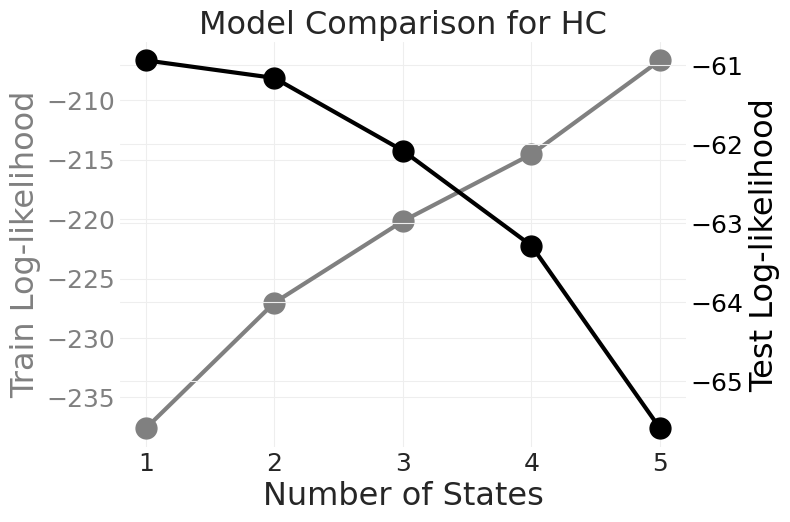

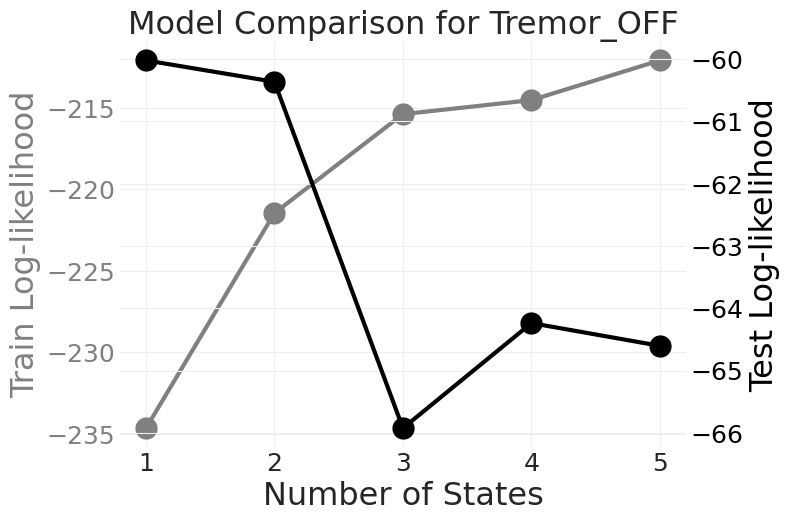

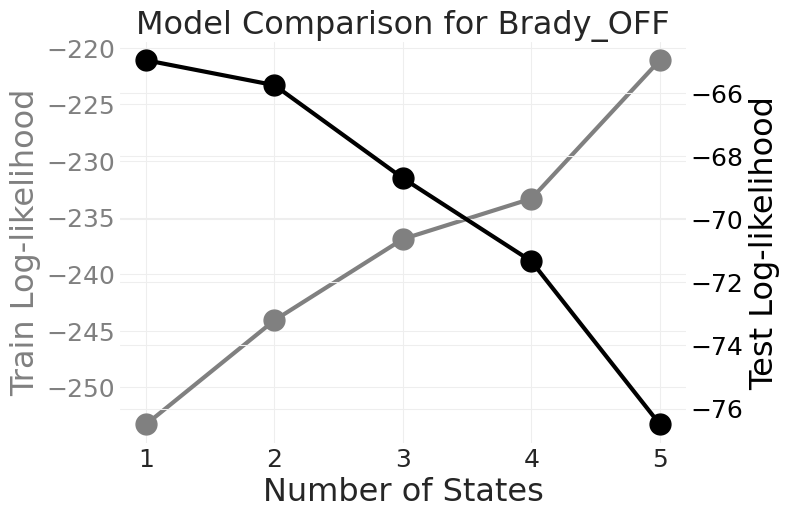

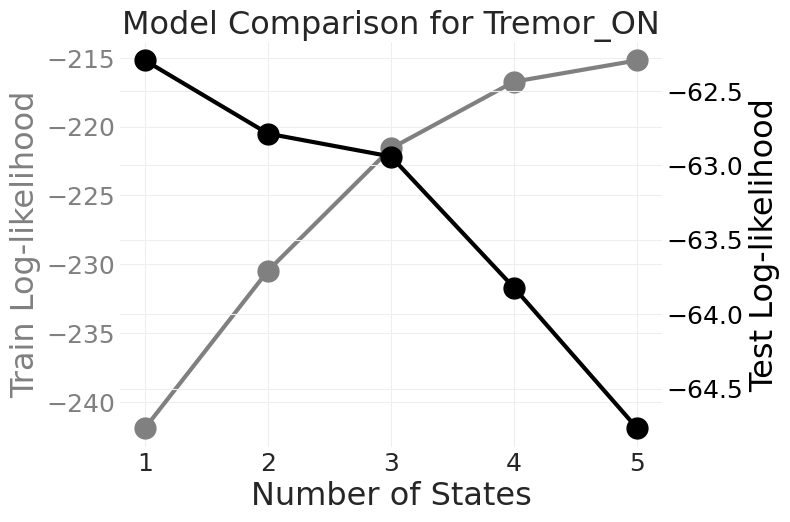

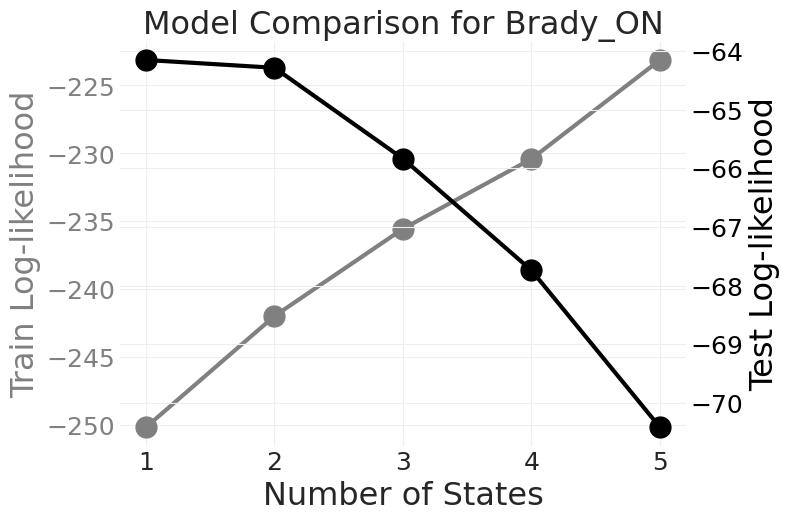

In [56]:
comparison_results = {}
for model_name, fitted_dict in models_and_data.items():
    fig, ax1, ax2, train_ll, test_ll, states = plot_model_comparison(fitted_dict)
    comparison_results[model_name] = {"train_ll": train_ll, "test_ll": test_ll, "states": states}
    plt.title(f"Model Comparison for {model_name}", fontsize=23)
    plt.show()

## Finalize states

"HC"